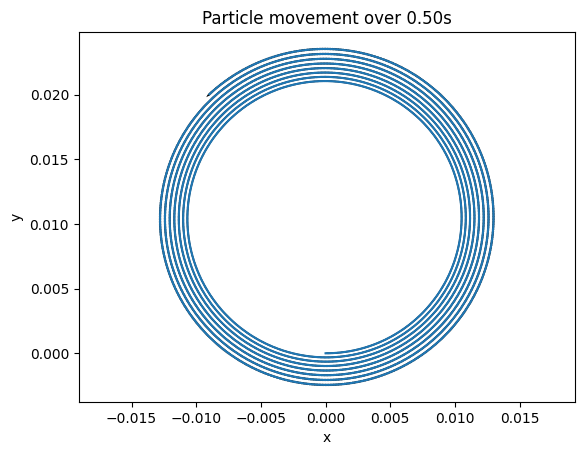

In [108]:
import numpy as np
import matplotlib.pyplot as plt

def advance_time(r0, v0, dt):
    # define variables
    B = np.array([0, 0, -1e-6]) # T
    q = 1.602e-19 # C
    m = 1.673e-27 # kg
    a = (q/m)*np.cross(v0, B)
    v1 = np.add(v0, a*dt)
    r1 = np.add(r0, v0*dt)
    return r1, v1

def simulate(r0, v0, dt, num_steps):
    r = r0
    v = v0
    traj_r = [r0]
    traj_v = [v0]
    for _ in range(num_steps):
        ri, vi = advance_time(r, v, dt)
        traj_r.append(ri)
        traj_v.append(vi)
        r, v = ri, vi

    r_path = np.array(traj_r)
    v_path = np.array(traj_v)

    x_positions = r_path[:, 0]
    y_positions = r_path[:, 1]
    u = v_path[:, 0]
    w = v_path[:, 1]

    plt.plot(x_positions, y_positions)
    plt.quiver(x_positions, y_positions, u, w)
    plt.axis('equal')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title(f'Particle movement over {dt*num_steps:.2f}s')
    plt.show()

r0 = np.array([0,0,0])
v0 = np.array([1,0,0])
dt = 0.0001

simulate(r0, v0, dt, 5000)